# Avaliação de Resultados do Método Híbrido
Neste notebook avaliamos os resultados de Multifoco, Estéreo Fotométrico e a Integração Híbrida usando os arquivos da pasta 'sharp' como referência.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
import cv2

# Adiciona o diretório raiz ao sys.path
project_root = '/home/lelis/Documents/Projetos/hybrid-stereo-method'
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from hybrid_stereo_method.infrastructure.io.image_io import read_fni_to_image_array
from hybrid_stereo_method.infrastructure.visualization import display_image

# Caminhos de saída da execução
result_dir = '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50'
sharp_dir = os.path.join(result_dir, 'sharp')

# Função para calcular o mapa de erro normalizado e o erro médio (MAE)
def calculate_error_map(pred, ref):
    if pred.shape != ref.shape:
        pred = cv2.resize(pred, (ref.shape[1], ref.shape[0]), interpolation=cv2.INTER_LINEAR)
    
    # Como os valores podem estar em escalas diferentes no código original, faremos o cálculo com base nos valores min-max
    # Para um MAE verdadeiro em MM, a escala deve ser rigorosamente física.
    # Aqui, normalizamos apenas para visualização e comparativo simples do erro relativo.
    pred_norm = cv2.normalize(pred, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    ref_norm = cv2.normalize(ref, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    
    err_map = np.abs(pred_norm - ref_norm)
    mae = np.nanmean(err_map)
    return mae, err_map


## 1. Ground Truth / Referência
Imagens da pasta 'sharp' para servirem de referência.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65535.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..257.0].


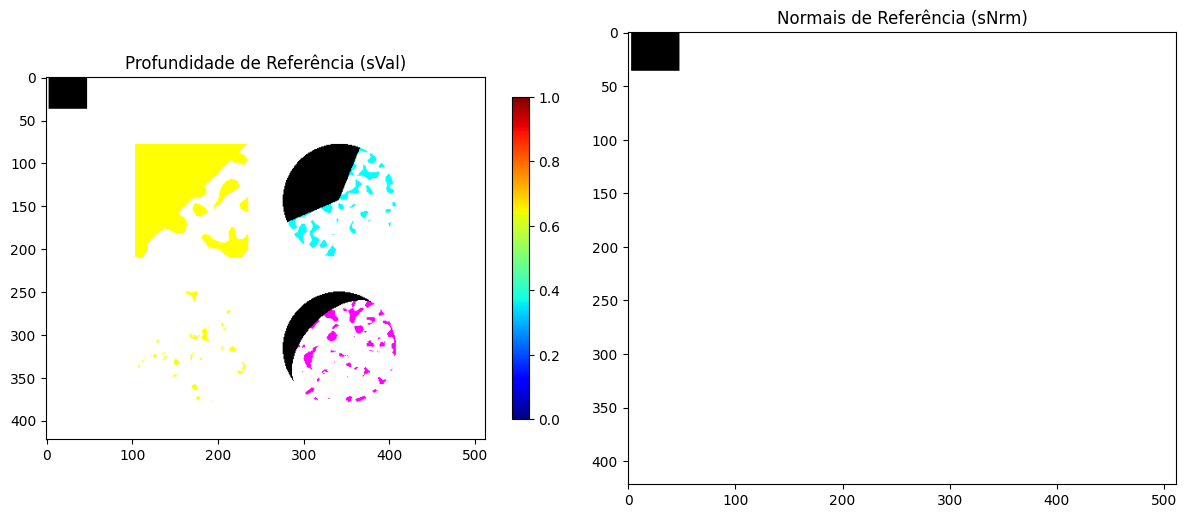

In [11]:
# Carrega arquivos de referência (sVal e sNrm)
ref_z_img = cv2.imread(os.path.join(sharp_dir, 'sVal.png'), cv2.IMREAD_UNCHANGED)
ref_z = ref_z_img.astype(float) if ref_z_img is not None else None

ref_nrm_img = cv2.imread(os.path.join(sharp_dir, 'sNrm.png'), cv2.IMREAD_UNCHANGED)
if ref_nrm_img is not None:
    ref_nrm = cv2.cvtColor(ref_nrm_img, cv2.COLOR_BGR2RGB).astype(float) / 255.0
else:
    ref_nrm = None

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
if ref_z is not None:
    im0 = ax[0].imshow(ref_z, cmap='jet')
    ax[0].set_title('Profundidade de Referência (sVal)')
    fig.colorbar(im0, ax=ax[0], shrink=0.7)
if ref_nrm is not None:
    ax[1].imshow(ref_nrm)
    ax[1].set_title('Normais de Referência (sNrm)')

plt.tight_layout()
plt.show()


## 2. Avaliação do Multifoco
Compara o arquivo de saída `zMos.fni` do multifoco com a referência de profundidade `sVal`.

In [12]:
mf_dir = os.path.join(result_dir, 'multifocus_stereo', 'average')
mf_z = read_fni_to_image_array(os.path.join(mf_dir, 'zMos.fni'))

if mf_z is not None and ref_z is not None:
    mae_mf, mf_err = calculate_error_map(mf_z, ref_z)
    print(f'Erro Médio (Normalizado) Multifoco: {mae_mf:.4f}')
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    im0 = ax[0].imshow(mf_z, cmap='jet')
    ax[0].set_title('Profundidade Multifoco (zMos.fni)')
    fig.colorbar(im0, ax=ax[0], shrink=0.7)
    
    im1 = ax[1].imshow(ref_z, cmap='jet')
    ax[1].set_title('Referência (sVal)')
    
    im2 = ax[2].imshow(mf_err, cmap='hot')
    ax[2].set_title('Mapa de Erro (Multifoco)')
    fig.colorbar(im2, ax=ax[2], shrink=0.7)
    
    plt.suptitle("Multifocus Stereo Evaluation")
    plt.tight_layout()
    plt.show()
else:
    print("Dados do multifoco (zMos) não encontrados para comparar.")


ValueError: invalid literal for int() with base 10: 'NC'

## 3. Avaliação do Estéreo Fotométrico
Compara o mapa de normais `normal_map_with_residuals.fni` do estéreo fotométrico com a referência `sNrm`.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..257.0].


Erro Euler (Distância L2) Fotométrico: 300.1644


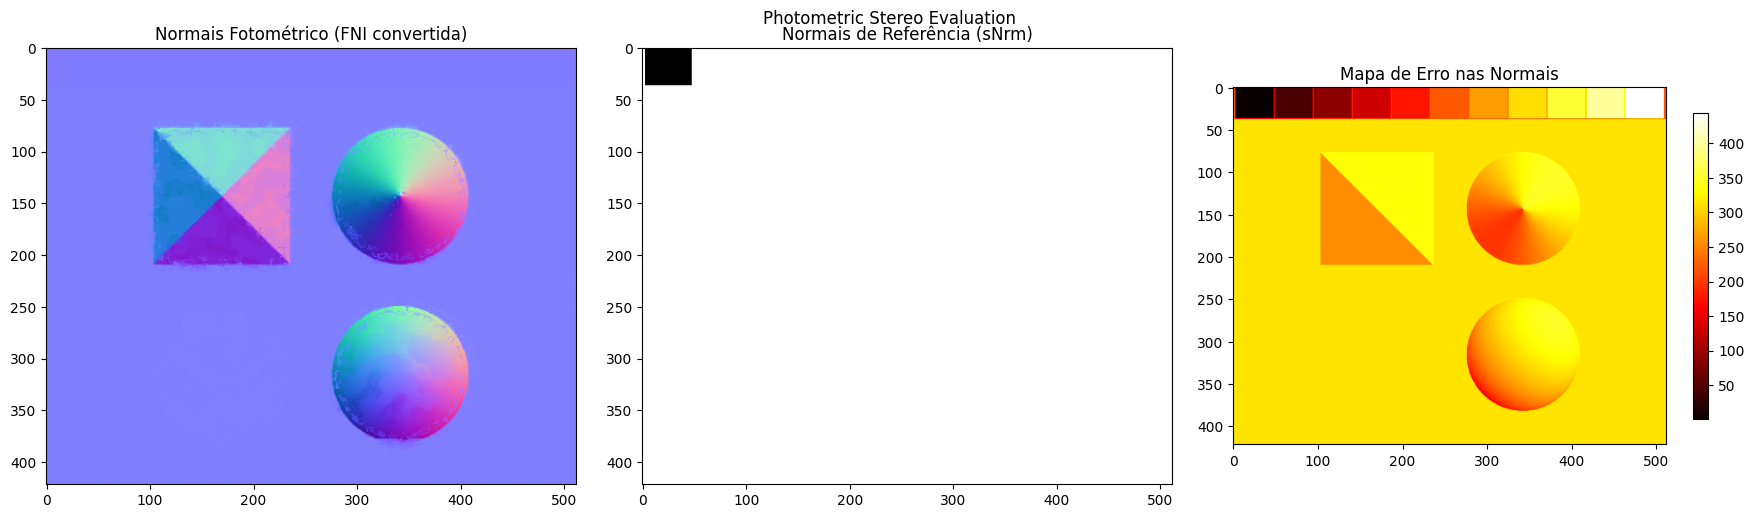

In [13]:
ps_dir = os.path.join(result_dir, 'photometric_stereo')
ps_nrm_file = os.path.join(ps_dir, 'normal_map_with_residuals.fni')
ps_nrm_data = read_fni_to_image_array(ps_nrm_file)

if ps_nrm_data is not None and ref_nrm is not None:
    if len(ps_nrm_data.shape) == 3 and ps_nrm_data.shape[2] >= 3:
        # As normais FNI estão nas 3 primeiras componentes
        ps_nrm = ps_nrm_data[:, :, :3]
        
        # Converter do range [-1, 1] para o [0, 1] para poder visualizar e comparar com a referência
        ps_nrm_vis = (ps_nrm + 1.0) / 2.0
        ps_nrm_vis = np.clip(ps_nrm_vis, 0, 1) # apenas para garantia
        
        # Calculando o erro absoluto por normal como distância euclidiana
        err_nrm = np.linalg.norm(ps_nrm_vis - ref_nrm, axis=2)
        mae_ps = np.nanmean(err_nrm)
        print(f'Erro Euler (Distância L2) Fotométrico: {mae_ps:.4f}')
        
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        ax[0].imshow(ps_nrm_vis)
        ax[0].set_title('Normais Fotométrico (FNI convertida)')
        
        ax[1].imshow(ref_nrm)
        ax[1].set_title('Normais de Referência (sNrm)')
        
        im2 = ax[2].imshow(err_nrm, cmap='hot')
        ax[2].set_title('Mapa de Erro nas Normais')
        fig.colorbar(im2, ax=ax[2], shrink=0.7)
        
        plt.suptitle("Photometric Stereo Evaluation")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Dados da normal têm formato inesperado: {ps_nrm_data.shape}")
else:
    print("Dados da normal (photometric) ou referência sNrm não encontrados.")


## 4. Avaliação Híbrida - Iterações e Resultado Final
Nesta seção, visualizamos o resultado de múltiplas iterações do processo de otimização híbrida sobre o mapa de profundidade, lado a lado com a respectiva evolução de erro.

In [14]:
hybrid_dir = os.path.join(result_dir, 'integration')

# Busca pelas iterações salvas pelo método
iter_files = sorted(glob.glob(os.path.join(hybrid_dir, 'height-iters', '*Z.fni')))
if not iter_files:
    iter_files = sorted(glob.glob(os.path.join(hybrid_dir, 'height-*Z.fni')))

if iter_files and ref_z is not None:
    print(f"Encontrados {len(iter_files)} arquivos de iteração/níveis do Híbrido.")
    
    max_to_display = 8
    step = max(1, len(iter_files) // max_to_display)
    display_files = iter_files[::step]
    if iter_files[-1] not in display_files:
        display_files.append(iter_files[-1])
        
    for f in display_files:
        hb_z = read_fni_to_image_array(f)
        if hb_z is not None:
            mae_hb, hb_err = calculate_error_map(hb_z, ref_z)
            
            fig, ax = plt.subplots(1, 3, figsize=(18, 4))
            im0 = ax[0].imshow(hb_z, cmap='jet')
            ax[0].set_title(f"Profundidade Híbrida\n{os.path.basename(f)}")
            fig.colorbar(im0, ax=ax[0])
            
            ax[1].imshow(ref_z, cmap='jet')
            ax[1].set_title('Referência (sVal)')
            
            im2 = ax[2].imshow(hb_err, cmap='hot')
            ax[2].set_title(f'Mapa de Erro (MAE={mae_hb:.4f})')
            fig.colorbar(im2, ax=ax[2])
            
            plt.tight_layout()
            plt.show()
else:
    print("Nenhuma iteração híbrida encontrada ou não há referência do sVal.")

# Avaliação Final (hAvg.fni)
print("-" * 80)
final_z_file = os.path.join(hybrid_dir, 'hAvg.fni')
final_z = read_fni_to_image_array(final_z_file)

if final_z is not None and ref_z is not None:
    mae_final, final_err = calculate_error_map(final_z, ref_z)
    print(f'Erro Médio Final (MAE) Híbrido: {mae_final:.4f}')
    
    fig, ax = plt.subplots(1, 4, figsize=(22, 5))
    
    # Também plota o multifoco para comparação direta com o resultado final do método
    if 'mf_z' in locals() and mf_z is not None:
        ax[0].imshow(mf_z, cmap='jet') 
    else: 
        ax[0].text(0.5, 0.5, 'N/A')
    ax[0].set_title('Profundidade Inicial (Multifoco)')
    
    im1 = ax[1].imshow(final_z, cmap='jet')
    ax[1].set_title('Resultado Final Híbrido\n(hAvg.fni)')
    fig.colorbar(im1, ax=ax[1], shrink=0.7)
    
    im2 = ax[2].imshow(ref_z, cmap='jet')
    ax[2].set_title('Referência (sVal)')
    
    im3 = ax[3].imshow(final_err, cmap='hot')
    ax[3].set_title('Mapa de Erro Inicial x Final')
    fig.colorbar(im3, ax=ax[3], shrink=0.7)
    
    plt.suptitle("Comparação Final do Método Híbrido")
    plt.tight_layout()
    plt.show()
else:
    print("Resultado híbrido final ('hAvg.fni') ou referência sVal não encontrados")


Encontrados 19 arquivos de iteração/níveis do Híbrido.


ValueError: operands could not be broadcast together with shapes (422,512,2) (422,512,3) 